In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(palette="Set2")

In [3]:
df = pd.read_csv("../data/Iris.csv", index_col="Id")
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


## Any missing values?

In [5]:
df.isna().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## Column data types

In [7]:
df.dtypes

SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

## Summary statistics

In [8]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [22]:
df.groupby("Species").describe().T

Species              Iris-setosa  Iris-versicolor  Iris-virginica
SepalLengthCm count    50.000000        50.000000       50.000000
              mean      5.006000         5.936000        6.588000
              std       0.352490         0.516171        0.635880
              min       4.300000         4.900000        4.900000
              25%       4.800000         5.600000        6.225000
              50%       5.000000         5.900000        6.500000
              75%       5.200000         6.300000        6.900000
              max       5.800000         7.000000        7.900000
SepalWidthCm  count    50.000000        50.000000       50.000000
              mean      3.418000         2.770000        2.974000
              std       0.381024         0.313798        0.322497
              min       2.300000         2.000000        2.200000
              25%       3.125000         2.525000        2.800000
              50%       3.400000         2.800000        3.000000
              75%       3.675000         3.000000        3.175000
              max       4.400000         3.400000        3.800000
PetalLengthCm count    50.000000        50.000000       50.000000
              mean      1.464000         4.260000        5.552000
              std       0.173511         0.469911        0.551895
              min       1.000000         3.000000        4.500000
              25%       1.400000         4.000000        5.100000
              50%       1.500000         4.350000        5.550000
              75%       1.575000         4.600000        5.875000
              max       1.900000         5.100000        6.900000
PetalWidthCm  count    50.000000        50.000000       50.000000
              mean      0.244000         1.326000        2.026000
              std       0.107210         0.197753        0.274650
              min       0.100000         1.000000        1.400000
              25%       0.200000         1.200000        1.800000
              50%       0.200000         1.300000        2.000000
              75%       0.300000         1.500000        2.300000
              max       0.600000         1.800000        2.500000

## Visualization

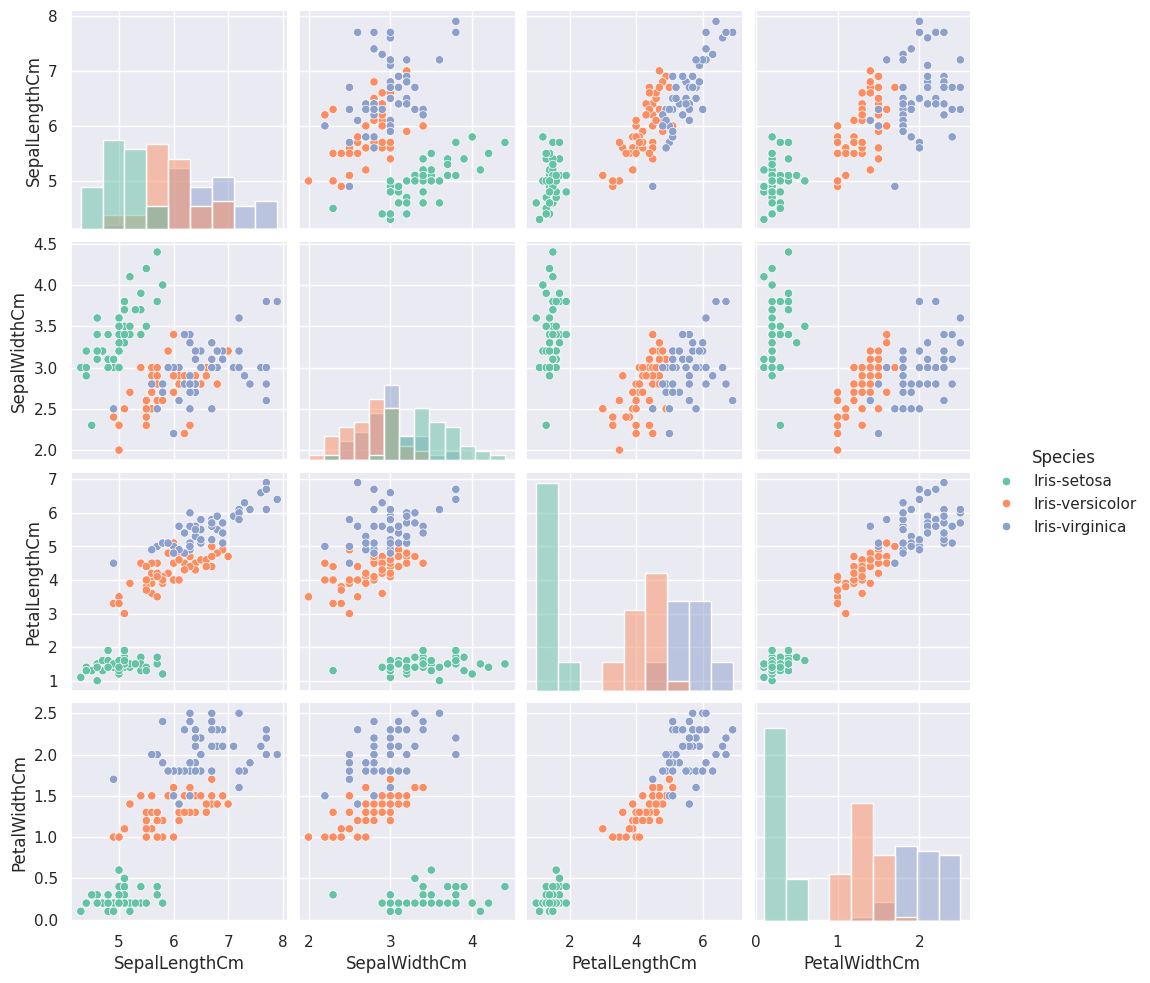

In [40]:
g = sns.pairplot(df, hue="Species", diag_kind="hist")

<Axes: >

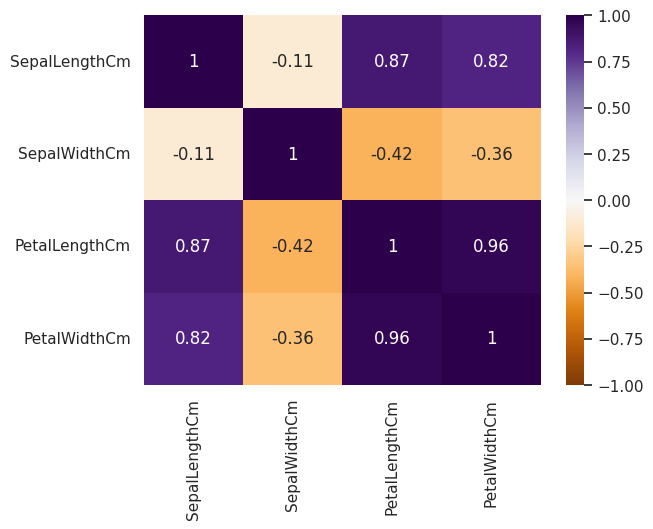

In [57]:
sns.heatmap(df.select_dtypes(include="number").corr(), vmin=-1, vmax=1, cmap="PuOr", annot=True)

We can see that `SepalLengthCm` has a very low correlation wtih `SepaWidthCm`, while `PetalLengthCm` is almost perfectly correlated with `PetalWidthCm`.

150
[0.99368988 0.99158113 0.51070243 0.31020793]


Text(0.5, 1.0, 'Mutual information of iris features and target Species')

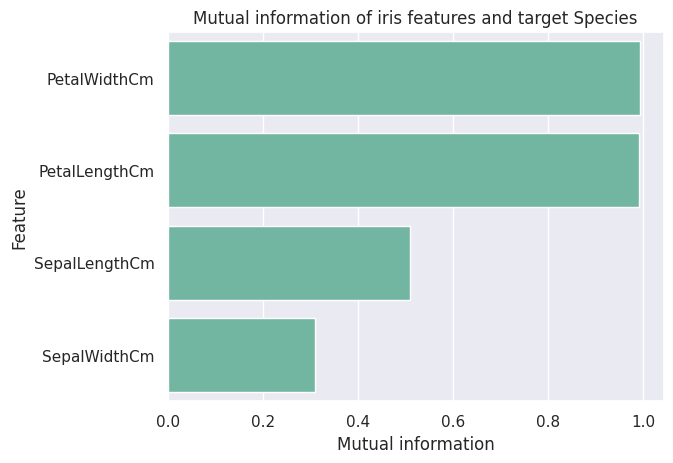

In [123]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns="Species")
y, uniques = pd.factorize(df["Species"])

mi = mutual_info_classif(X, y)
sorted_mi_idxs = np.argsort(mi)[::-1]
print(mi[sorted_mi_idxs])

ax = sns.barplot(y=df.columns[sorted_mi_idxs], x=mi[sorted_mi_idxs], orient="h")
ax.set_xlabel("Mutual information")
ax.set_ylabel("Feature")
ax.set_title("Mutual information of iris features and target Species")

`PetalLengthCm` and `PetalWidthCm` have the highest mutual information with the target variable `Species`. This, combined with the correlation matrix that we computed previously, makes me want to try a 3 feature model, using the sepal features due to their low correlation and `PetalLengthCm` because it has the highest mutual information with `Species`.

Still, since the dataset is so small, I think it is a good opportunity to try out all possible subsets of features to find the best one.

In [168]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipepline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

logistic_regression = LogisticRegression(tol=1e-4, C=1.0, solver="lbfgs", max_iter=100)
scores = cross_val_score(logistic_regression, X=X_train, y=y_train, cv=5)
print(scores.mean())

logistic_regression.fit(X_train, y_train)
print(logistic_regression.n_iter_)

0.95
[86]


In [110]:
rng = np.random.RandomState(1338)
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm

def plot_cv_indices(cv, X, y, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2,
        )

    # Plot the data classes and groups at the end
    ax.scatter(
        range(len(X)), [ii + 1.5] * len(X), c=y, marker="_", lw=lw, cmap=cmap_data
    )

    # Formatting
    yticklabels = list(range(n_splits)) + ["class"]
    ax.set(
        yticks=np.arange(n_splits + 1) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample index",
        ylabel="CV iteration",
        ylim=[n_splits + 1.1, -0.2],
        xlim=[0, len(X)],
    )
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax



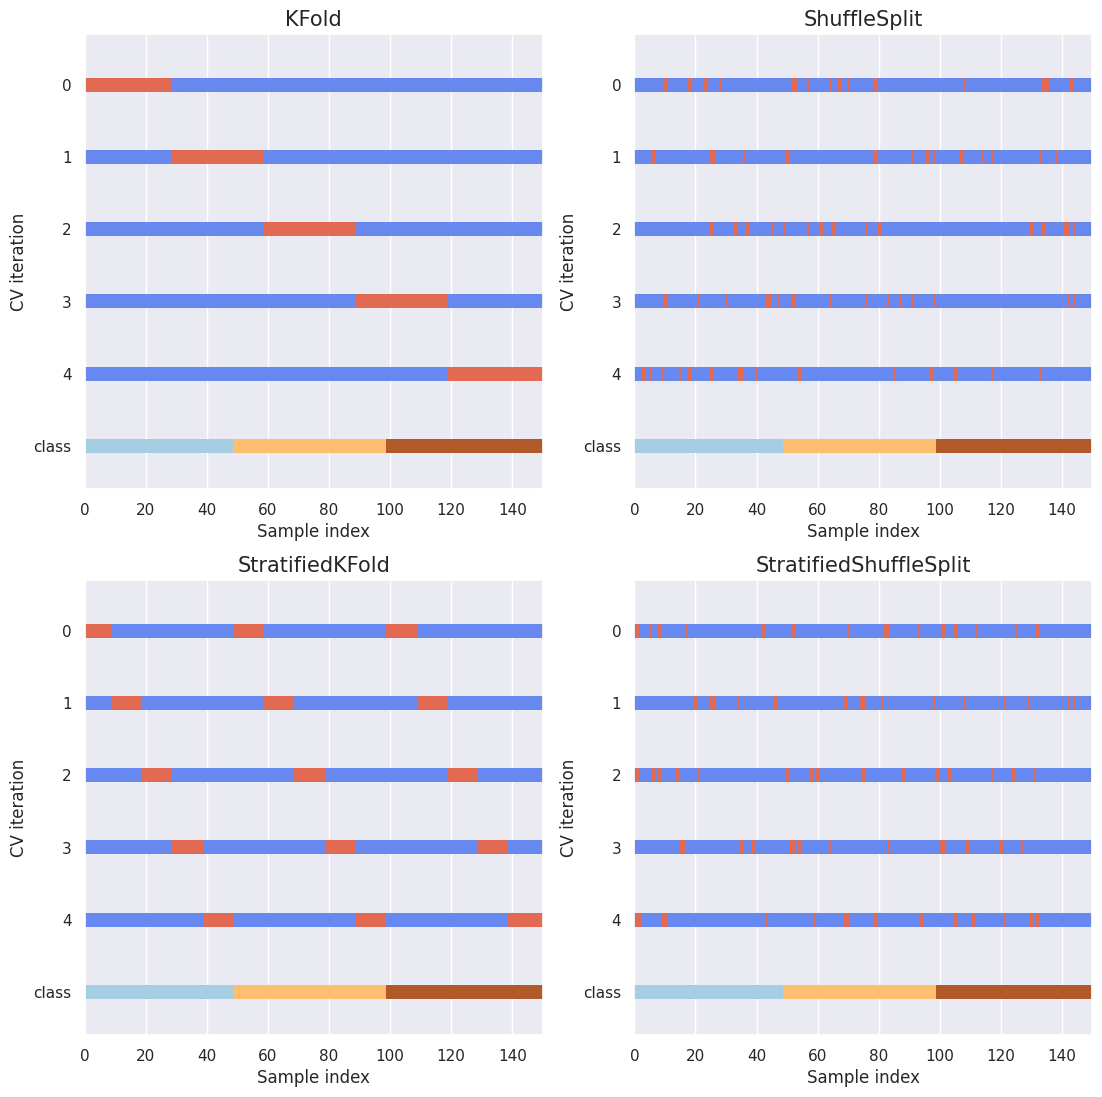

In [117]:
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    StratifiedKFold,
    StratifiedShuffleSplit,
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 13))
n_splits = 5

cvs = [algo(n_splits) for algo in [KFold, ShuffleSplit, StratifiedKFold, StratifiedShuffleSplit]]

for i in range(2):
    for j in range(2):
        plot_cv_indices(cvs[2 * i + j], X, y, axes[i][j], n_splits)

🔍 Performing Grid Search on training set...

Logistic Regression: 0.9583 (CV) with params {'model__C': 10, 'model__solver': 'lbfgs'}
SVC: 0.9667 (CV) with params {'model__C': 1, 'model__kernel': 'linear'}
KNN: 0.9417 (CV) with params {'model__n_neighbors': 6}
Random Forest: 0.9583 (CV) with params {'max_depth': 2, 'n_estimators': 50}
Gradient Boosting: 0.9583 (CV) with params {'learning_rate': 0.05, 'n_estimators': 100}
Decision Tree: 0.9583 (CV) with params {'max_depth': 2}
Gaussian NB: 0.9500 (CV) with params {}
LDA: 0.9667 (CV) with params {}
MLP (Neural Net): 0.9583 (CV) with params {'model__alpha': 0.001, 'model__hidden_layer_sizes': (100,)}

✅ Best model: SVC
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro

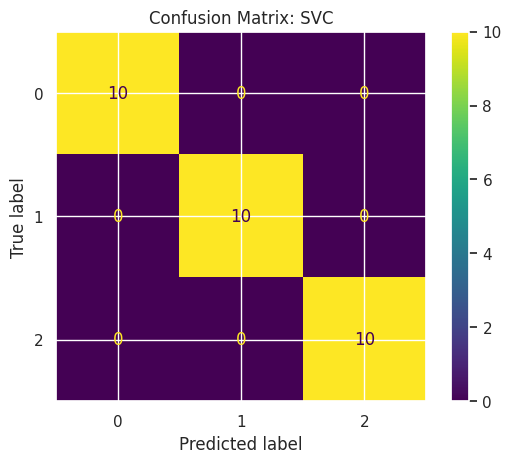

/tmp/ipykernel_472762/2808061731.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=model_names, palette='viridis')


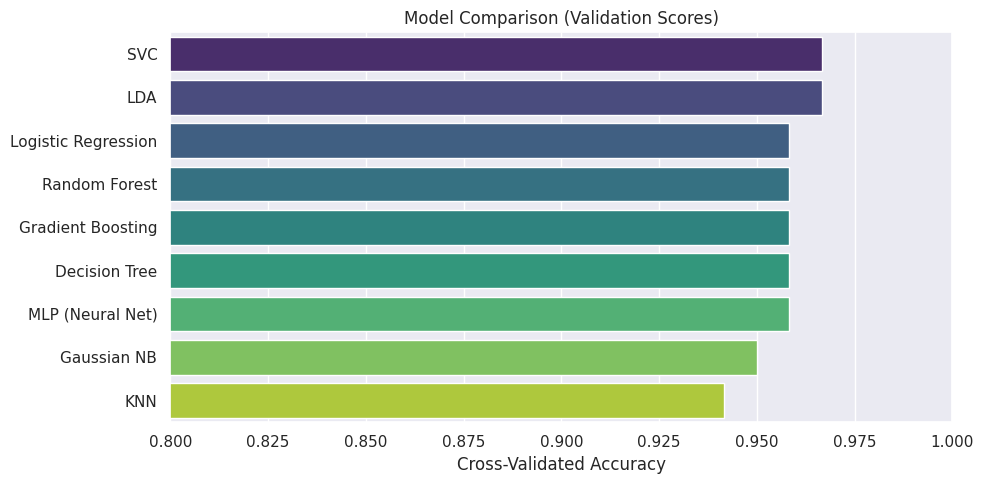

['svc_best_model.pkl']

In [183]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

# Define models + pipelines + parameter grids
candidates = {
    "Logistic Regression": {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000))
        ]),
        'params': {
            'model__C': [0.1, 1.0, 10],
            'model__solver': ['lbfgs']
        }
    },
    "SVC": {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC())
        ]),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf']
        }
    },
    "KNN": {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier())
        ]),
        'params': {
            'model__n_neighbors': list(range(1, 11))
        }
    },
    "Random Forest": {
        'pipeline': RandomForestClassifier(),
        'params': {
            'n_estimators': [50, 100, 200, 500],
            'max_depth': [None] + list(range(2, 6))
        }
    },
    "Gradient Boosting": {
        'pipeline': GradientBoostingClassifier(),
        'params': {
            'n_estimators': [50, 100, 200, 500],
            'learning_rate': [0.05, 0.1]
        }
    },
    "Decision Tree": {
        'pipeline': DecisionTreeClassifier(),
        'params': {
            'max_depth': [None] + list(range(2, 6))
        }
    },
    "Gaussian NB": {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', GaussianNB())
        ]),
        'params': {}
    },
    "LDA": {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LDA())
        ]),
        'params': {}
    },
    "MLP (Neural Net)": {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(max_iter=1000))
        ]),
        'params': {
            'model__hidden_layer_sizes': [(50,), (100,)],
            'model__alpha': [0.0001, 0.001]
        }
    }
}

# Evaluate all models on training set using GridSearchCV
results = {}
best_score = -np.inf
best_model = None
best_name = ""

print("🔍 Performing Grid Search on training set...\n")

for name, cfg in candidates.items():
    grid = GridSearchCV(cfg['pipeline'], cfg['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    mean_acc = grid.best_score_
    results[name] = {
        'best_score': mean_acc,
        'best_params': grid.best_params_,
        'best_estimator': grid.best_estimator_
    }

    print(f"{name}: {mean_acc:.4f} (CV) with params {grid.best_params_}")

    if mean_acc > best_score:
        best_score = mean_acc
        best_model = grid.best_estimator_
        best_name = name

# 🎯 Test set evaluation
y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n✅ Best model: {best_name}")
print(f"Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"Confusion Matrix: {best_name}")
plt.show()

# 📊 Plot all CV scores
sorted_results = sorted(results.items(), key=lambda kv: kv[1]['best_score'], reverse=True)
model_names = [k for k, _ in sorted_results]
scores = [v['best_score'] for _, v in sorted_results]

plt.figure(figsize=(10, 5))
sns.barplot(x=scores, y=model_names, palette='viridis')
plt.xlabel("Cross-Validated Accuracy")
plt.title("Model Comparison (Validation Scores)")
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

# 💾 Save best model
joblib.dump(best_model, f"{best_name.replace(' ', '_').lower()}_best_model.pkl")


In [175]:
from pprint import pprint
pprint(sorted_results)

[('SVC',
  {'best_estimator': Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(C=1, kernel='linear'))]),
   'best_params': {'model__C': 1, 'model__kernel': 'linear'},
   'best_score': np.float64(0.9666666666666668)}),
 ('LDA',
  {'best_estimator': Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LinearDiscriminantAnalysis())]),
   'best_params': {},
   'best_score': np.float64(0.9666666666666668)}),
 ('Logistic Regression',
  {'best_estimator': Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(C=10, max_iter=1000))]),
   'best_params': {'model__C': 10, 'model__solver': 'lbfgs'},
   'best_score': np.float64(0.9583333333333334)}),
 ('Random Forest',
  {'best_estimator': RandomForestClassifier(max_depth=2, n_estimators=50),
   'best_params': {'max_depth': 2, 'n_estimators': 50},
   'best_score': np.float64(0.9583333333333334)}),
 ('Gradient Boosting',
  {'best_estimator': GradientBoostingClassifier(

## 